#### Data Integration and Supply Risk Modeling

#### Overview

This notebook combines:

- 1: FDA shortage data (demand-side signals)
- 2: Orange Book data (supply-side features)

The objective is to build a predictive model for drug shortage risk.

#### Approach

1. Merge datasets
2. Engineer temporal and supply-side features
3. Build predictive models
4. Generate risk scores for decision-making

In [73]:
#importing all requirements

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_curve
)

import seaborn as sns
from joblib import dump
from sklearn.calibration import CalibratedClassifierCV


In [74]:
#reading the data from v1

shortage_data = pd.read_csv("shortage_data.csv")

In [75]:
#reading the data from v2

manufacturer_counts = pd.read_csv("manufacturer_counts.csv")

#### Merging the two

In [76]:
#cleaning name from shortage data

shortage_data['generic_clean'] = (
    shortage_data['generic_name']
    .str.upper()
    .str.strip()
    .str.replace(r'\s*;\s*', ';', regex=True) 
)

In [77]:
#joining using the name of drugs

df_merged = shortage_data.merge(
    manufacturer_counts,
    left_on='generic_clean',
    right_on='ingredient_clean',
    how = 'left'
)

In [78]:
#100% mismatch :(

missing_percentage = df_merged['true_manufacturer_count'].isna().mean()
missing_percentage

1.0

In [79]:
#creating a cleaner version of the name to merge

def clean_generic_name(name):
    name = name.upper().strip()

    #removing dosage words
    remove_words = [
         'INJECTION', 'TABLET', 'CAPSULE', 'SOLUTION', 
        'SUSPENSION', 'SYRUP', 'CREAM', 'OINTMENT',
        'POWDER', 'FOR', 'CONCENTRATE', 'KIT',
        'AUTO-INJECTOR', 'VIAL'
    ]

    for word in remove_words:
        name = re.sub(r'\b' + word + r'\b', '', name)
    
    #normalize spacing
    name = re.sub(r'\s+', ' ', name).strip()

    #remove percentages
    name = re.sub(r'\d+(\.\d+)?\s*%', '', name)

    #normalize separators
    name = name.replace(',', ';')

    #remove trailing descriptors after comma/semicolon split
    name = name.split(';')[0]

    #clean spaces
    name = re.sub(r'\s+', ' ', name).strip()

    return name 

In [80]:
#applying the function

shortage_data['generic_clean'] = shortage_data['generic_name'].apply(clean_generic_name)

shortage_data['generic_clean'] = (
    shortage_data['generic_clean']
    .str.replace(r'\s*;\s*', ';', regex=True)
)

In [81]:
#joining again

df_merged = df_merged.drop(columns = ['true_manufacturer_count'], errors = 'ignore')

df_merged = shortage_data.merge(
    manufacturer_counts,
    left_on='generic_clean',
    right_on='ingredient_clean',
    how = 'left'
)

##### Merge Limitation

Approximately 18% of records could not be matched across datasets.

These were assigned a default manufacturer count of 1

In [82]:
#18% mismatch

missing_percentage = df_merged['true_manufacturer_count'].isna().mean()
missing_percentage

0.18446026097271648

In [83]:
df_merged[['generic_name', 'generic_clean', 'true_manufacturer_count']].head(20)

,generic_name,generic_clean,true_manufacturer_count
0,Dextrose Monohydrate 5% Injection,DEXTROSE MONOHYDRATE,NaN
1,Ropivacaine Hydrochloride Injection,ROPIVACAINE HYDROCHLORIDE,13.0
2,Lidocaine Hydrochloride Injection,LIDOCAINE HYDROCHLORIDE,28.0
3,Lisdexamfetamine Dimesylate Capsule,LISDEXAMFETAMINE DIMESYLATE,20.0
4,Atropine Sulfate Injection,ATROPINE SULFATE,14.0
5,Lisdexamfetamine Dimesylate Capsule,LISDEXAMFETAMINE DIMESYLATE,20.0
6,"Lisdexamfetamine Dimesylate Tablet, Chewable",LISDEXAMFETAMINE DIMESYLATE,20.0
7,Sterile Water Injection,STERILE WATER,NaN
8,"Bupivacaine Hydrochloride, Epinephrine Bitartr...",BUPIVACAINE HYDROCHLORIDE,10.0
9,Ketorolac Tromethamine Injection,KETOROLAC TROMETHAMINE,23.0


In [85]:
#replacing NULLS with 1

df_merged['true_manufacturer_count'] = (
    df_merged['true_manufacturer_count'].fillna(1)
)

In [86]:
#normalizing distribution
#for logistic regression

df_merged['log_manufacturer_count'] = np.log1p(df_merged['true_manufacturer_count'])

In [87]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   package_ndc              1686 non-null   object 
 1   generic_name             1686 non-null   object 
 2   dosage_form              1675 non-null   object 
 3   presentation             1686 non-null   object 
 4   company_name             1686 non-null   object 
 5   initial_posting_date     1686 non-null   object 
 6   update_date              1686 non-null   object 
 7   discontinued_date        503 non-null    object 
 8   availability             1142 non-null   object 
 9   status                   1686 non-null   object 
 10  shortage_reason          1686 non-null   object 
 11  therapeutic_category     1686 non-null   object 
 12  update_type              1686 non-null   object 
 13  related_info             1120 non-null   object 
 14  shortage                

##### Feature Engineering
- Supply-side risk = manufacturer count
- Temporal risk = recency of shortages
- Demand signals = therapeutic category trends
- Operational causes = shortage reasons


In [88]:
#creating new feature = days since shortage
#converting data type

df_merged['initial_posting_date'] = pd.to_datetime(df_merged['initial_posting_date'])

In [89]:
#sorting by date

df_merged = df_merged.sort_values(['generic_name', 'initial_posting_date'])

In [90]:
#shoft date down by one row for each drug

df_merged['prev_shortage_date'] = (
    df_merged.groupby('generic_name')['initial_posting_date']
    .shift(1)
)

In [91]:
#calc no of days

df_merged['days_since_last_shortage'] = (
    df_merged['initial_posting_date'] - df_merged['prev_shortage_date']
).dt.days

In [92]:
df_merged['days_since_last_shortage'] = (
    df_merged['days_since_last_shortage'].fillna(9999)
)

In [93]:
df_merged['log_days_since_last_shortage'] = np.log1p(df_merged['days_since_last_shortage'])

In [94]:
df_merged[['generic_name', 'initial_posting_date', 'days_since_last_shortage']].head(20)

,generic_name,initial_posting_date,days_since_last_shortage
1240,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,9999.0
1242,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,0.0
1243,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,0.0
1244,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,0.0
1248,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,0.0
1250,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,0.0
1673,Adalimumab-adaz Injection,2025-04-14,9999.0
1674,Adalimumab-adaz Injection,2025-04-14,0.0
1675,Adalimumab-adaz Injection,2025-04-14,0.0
1088,Adalimumab-adaz Injection,2026-01-13,274.0


In [95]:
#same drug, date, manufacturer
#but multiple records 
#NDC diff = same drug, with diff packaging, strengths, etc
#same shortage event and same drug

df_merged[df_merged['generic_name'] == 'Acetaminophen; Oxycodone Hydrochloride Tablet']

,package_ndc,generic_name,dosage_form,presentation,company_name,initial_posting_date,update_date,discontinued_date,availability,status,...,log_drug_freq,complexity_Low,complexity_Medium,generic_clean,ingredient_clean,true_manufacturer_count,log_manufacturer_count,prev_shortage_date,days_since_last_shortage,log_days_since_last_shortage
1240,60951-712-70,Acetaminophen; Oxycodone Hydrochloride Tablet,Tablet,"Acetaminophen; Oxycodone Hydrochloride, Tablet...","Endo Pharmaceuticals, Inc.",2025-11-03,2025-11-03,2025-11-03,NaN,To Be Discontinued,...,1.94591,True,False,ACETAMINOPHEN,ACETAMINOPHEN,20.0,3.044522,NaT,9999.0,9.21034
1242,60951-700-70,Acetaminophen; Oxycodone Hydrochloride Tablet,Tablet,"Acetaminophen; Oxycodone Hydrochloride, Tablet...","Endo Pharmaceuticals, Inc.",2025-11-03,2025-11-03,2025-11-03,NaN,To Be Discontinued,...,1.94591,True,False,ACETAMINOPHEN,ACETAMINOPHEN,20.0,3.044522,2025-11-03,0.0,0.00000
1243,60951-602-70,Acetaminophen; Oxycodone Hydrochloride Tablet,Tablet,"Acetaminophen; Oxycodone Hydrochloride, Tablet...","Endo Pharmaceuticals, Inc.",2025-11-03,2025-11-03,2025-11-03,NaN,To Be Discontinued,...,1.94591,True,False,ACETAMINOPHEN,ACETAMINOPHEN,20.0,3.044522,2025-11-03,0.0,0.00000
1244,60951-701-70,Acetaminophen; Oxycodone Hydrochloride Tablet,Tablet,"Acetaminophen; Oxycodone Hydrochloride, Tablet...","Endo Pharmaceuticals, Inc.",2025-11-03,2025-11-03,2025-11-03,NaN,To Be Discontinued,...,1.94591,True,False,ACETAMINOPHEN,ACETAMINOPHEN,20.0,3.044522,2025-11-03,0.0,0.00000
1248,63481-627-70,Acetaminophen; Oxycodone Hydrochloride Tablet,Tablet,"Acetaminophen; Oxycodone Hydrochloride, Tablet...","Endo Pharmaceuticals, Inc.",2025-11-03,2025-11-03,2025-11-03,NaN,To Be Discontinued,...,1.94591,True,False,ACETAMINOPHEN,ACETAMINOPHEN,20.0,3.044522,2025-11-03,0.0,0.00000
1250,60951-602-85,Acetaminophen; Oxycodone Hydrochloride Tablet,Tablet,"Acetaminophen; Oxycodone Hydrochloride, Tablet...","Endo Pharmaceuticals, Inc.",2025-11-03,2025-11-03,2025-11-03,NaN,To Be Discontinued,...,1.94591,True,False,ACETAMINOPHEN,ACETAMINOPHEN,20.0,3.044522,2025-11-03,0.0,0.00000


In [96]:
#0s = duplicates
#drop to create unique drug + shortage date dataset

df_events = df_merged[['generic_name', 'initial_posting_date']].drop_duplicates()

In [97]:
#repeating steps

df_events = df_events.sort_values(['generic_name', 'initial_posting_date'])

df_events['prev_shortage_date'] = (
    df_events.groupby('generic_name')['initial_posting_date']
    .shift(1)
)

df_events['days_since_last_shortage'] = (
    df_events['initial_posting_date'] - df_events['prev_shortage_date']
).dt.days

df_events['days_since_last_shortage'] = (
    df_events['days_since_last_shortage'].fillna(9999)
)

In [101]:
#joining with dataset, ensuring that duplicate records get same value

df_merged = df_merged.merge(
    df_events[['generic_name', 'initial_posting_date', 'days_since_last_shortage']],
    on=['generic_name', 'initial_posting_date'],
    how='left'
)

In [102]:
#0 gaps remain

(df_merged['days_since_last_shortage'] == 0).sum()

0

In [103]:
#cases of first time shortage

(df_merged['days_since_last_shortage'] == 9999).sum()

1508

In [104]:
df_merged[['generic_name', 'initial_posting_date', 'days_since_last_shortage']].head(20)

,generic_name,initial_posting_date,days_since_last_shortage
0,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,9999.0
1,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,9999.0
2,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,9999.0
3,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,9999.0
4,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,9999.0
5,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,9999.0
6,Adalimumab-adaz Injection,2025-04-14,9999.0
7,Adalimumab-adaz Injection,2025-04-14,9999.0
8,Adalimumab-adaz Injection,2025-04-14,9999.0
9,Adalimumab-adaz Injection,2026-01-13,274.0


In [105]:
df_merged['log_days_since_last_shortage'] = np.log1p(df_merged['days_since_last_shortage'])

In [106]:
#feature 2 = 12m rolling counts

#removing duplicates, cannot count same shortage event multiple times

df_events = df_merged[['generic_name', 'initial_posting_date']].drop_duplicates()
df_events = df_events.sort_values(['generic_name', 'initial_posting_date'])

In [107]:
#counting shortages in 12 months

rolling_counts = []

for drug, group in df_events.groupby('generic_name'):
    dates = group['initial_posting_date'].values
    
    counts = []
    for i in range(len(dates)):
        window_start = dates[i] - np.timedelta64(365, 'D')
        count = np.sum((dates >= window_start) & (dates < dates[i]))
        counts.append(count)
    
    rolling_counts.extend(counts)

df_events['rolling_shortage_12m'] = rolling_counts

In [108]:
df_events[['generic_name', 'initial_posting_date', 'rolling_shortage_12m']].head(20)

,generic_name,initial_posting_date,rolling_shortage_12m
0,Acetaminophen; Oxycodone Hydrochloride Tablet,2025-11-03,0
6,Adalimumab-adaz Injection,2025-04-14,0
9,Adalimumab-adaz Injection,2026-01-13,1
14,Adalimumab-afzb Injection,2025-10-09,0
15,Adalimumab-ryvk Kit,2025-11-13,0
16,Adefovir Dipivoxil Tablet,2025-07-29,0
17,Albuterol Sulfate Solution,2022-10-25,0
20,Allopurinol Tablet,2026-02-19,0
24,Amantadine Hydrochloride Capsule,2025-07-23,0
26,Amantadine Hydrochloride Tablet,2025-07-23,0


In [109]:
#joining with df 

df_merged = df_merged.merge(
    df_events[['generic_name', 'initial_posting_date', 'rolling_shortage_12m']],
    on=['generic_name', 'initial_posting_date'],
    how='left'
)

In [110]:
df_merged['log_rolling_shortage_12m'] = np.log1p(df_merged['rolling_shortage_12m'])

In [111]:
#feature 3 = future shortage target

df_merged = df_merged.sort_values(['generic_name', 'initial_posting_date'])

#assigning next shortage value to the current row
df_merged['future_shortage'] = (
    df_merged.groupby('generic_name')['shortage'].shift(-1)
)

#remove event where future is not known
df_merged = df_merged.dropna(subset=['future_shortage'])

df_merged['future_shortage'] = df_merged['future_shortage'].astype(int)

In [112]:
#feature 4 = drug age 
 
# convert approval date
df_merged['initial_posting_date'] = pd.to_datetime(df_merged['initial_posting_date'], errors='coerce')

# extract year
df_merged['approval_year'] = df_merged['initial_posting_date'].dt.year

# compute age
current_year = df_merged['initial_posting_date'].dt.year
df_merged['drug_age'] = current_year - df_merged['approval_year']

# fill missing
df_merged['drug_age'] = df_merged['drug_age'].fillna(df_merged['drug_age'].median())

In [113]:
#feature 5 = shortage reason

df_merged['shortage_reason'] = df_merged['shortage_reason'].fillna("").str.lower()

df_merged['reason_manufacturing'] = df_merged['shortage_reason'].str.contains('manufactur').astype(int)
df_merged['reason_quality'] = df_merged['shortage_reason'].str.contains('quality').astype(int)
df_merged['reason_demand'] = df_merged['shortage_reason'].str.contains('demand').astype(int)
df_merged['reason_unknown'] = (df_merged['shortage_reason'] == "").astype(int)

##### Manufacturer Risk

Manufacturer risk = historical shortage rates up to each point in time

Prevents data leakage and ensures the model only uses past information

In [141]:
#feature 6 = manufacturer shortage rate

# Sort first
df_merged = df_merged.sort_values(['company_name', 'initial_posting_date'])

# Expanding mean (only past)
df_merged['manufacturer_risk'] = (
    df_merged.groupby('company_name')['shortage']
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)

df_merged['manufacturer_risk'] = df_merged['manufacturer_risk'].fillna(0)

In [156]:
#feature 7 = demand proxy

category_demand = (
    df_merged.groupby('therapeutic_category')['shortage']
    .mean()
    .reset_index()
    .rename(columns={'shortage': 'category_demand_score'})
)

# merge back
df_merged = df_merged.merge(category_demand, on='therapeutic_category', how='left')

In [143]:
#feature 8, 9, 10 = formulation

df_merged['dosage_form'] = df_merged['dosage_form'].fillna("").str.lower()

df_merged['is_injectable'] = df_merged['dosage_form'].str.contains('injection').astype(int)
df_merged['is_tablet'] = df_merged['dosage_form'].str.contains('tablet').astype(int)
df_merged['is_capsule'] = df_merged['dosage_form'].str.contains('capsule').astype(int)

In [144]:
#manufacturer risk * count

df_merged['manufacturer_risk_scaled'] = (
    df_merged['manufacturer_risk'] * df_merged['log_manufacturer_count']
)

#### Final Data Validation

In [145]:
df_merged.shape

(1443, 46)

In [146]:
missing = df_merged.isna().mean().sort_values(ascending=False)
missing[missing > 0]

discontinued_date     0.769924
related_info          0.361053
availability          0.255024
ingredient_clean      0.169785
prev_shortage_date    0.118503
dtype: float64

In [152]:
df_merged['future_shortage'].value_counts(normalize=True)

future_shortage
0    0.738739
1    0.261261
Name: proportion, dtype: float64

In [ ]:
#removing the features that have no impact

features = [
    'log_manufacturer_count',
    'log_days_since_last_shortage',
    #'log_rolling_shortage_12m',
    'complexity_Low',
    'complexity_Medium',
    
    #'drug_age',
    'manufacturer_risk',
    'category_demand_score',
    
    'reason_manufacturing',
    #'reason_quality',
    'reason_demand',
    
    'is_injectable',
    'is_tablet',
    'is_capsule',
    
    'manufacturer_risk_scaled'
]

In [158]:
df_merged[features].describe().T

,count,mean,std,min,25%,50%,75%,max
log_manufacturer_count,1443.0,2.335669,0.943863,0.693147,1.609438,2.639057,3.044522,3.713572
log_days_since_last_shortage,1443.0,8.758905,1.547031,0.693147,9.210340,9.210340,9.210340,9.210340
manufacturer_risk,1443.0,0.289943,0.282195,0.000000,0.000000,0.225806,0.471772,1.000000
category_demand_score,1443.0,0.258489,0.153343,0.000000,0.191358,0.255814,0.358974,1.000000
reason_manufacturing,1443.0,0.035343,0.184709,0.000000,0.000000,0.000000,0.000000,1.000000
reason_demand,1443.0,0.063756,0.244403,0.000000,0.000000,0.000000,0.000000,1.000000
is_injectable,1443.0,0.588358,0.492302,0.000000,0.000000,1.000000,1.000000,1.000000
is_tablet,1443.0,0.272349,0.445323,0.000000,0.000000,0.000000,1.000000,1.000000
is_capsule,1443.0,0.097713,0.297029,0.000000,0.000000,0.000000,0.000000,1.000000
manufacturer_risk_scaled,1443.0,0.664218,0.731692,0.000000,0.000000,0.447940,1.120742,3.555348


In [159]:
df_merged.duplicated(subset=['generic_name', 'initial_posting_date']).sum()

1233

In [160]:
df_merged[['manufacturer_risk']].describe()

,manufacturer_risk
count,1443.000000
mean,0.289943
std,0.282195
min,0.000000
25%,0.000000
50%,0.225806
75%,0.471772
max,1.000000


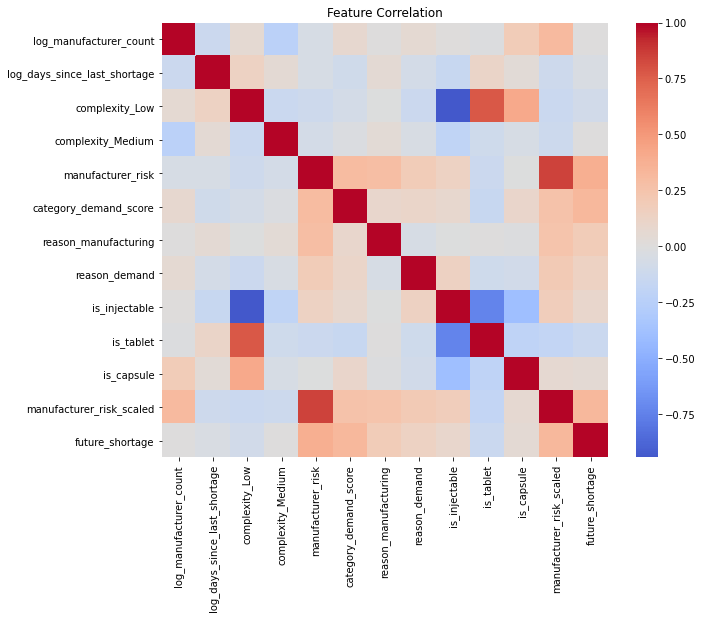

In [161]:
corr = df_merged[features + ['future_shortage']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation")
plt.show()

In [162]:
for col in ['manufacturer_risk', 'category_demand_score', 'log_manufacturer_count']:
    print("\n", col)
    print(df_merged.groupby('future_shortage')[col].mean())


 manufacturer_risk
future_shortage
0    0.225212
1    0.472974
Name: manufacturer_risk, dtype: float64

 category_demand_score
future_shortage
0    0.228343
1    0.343730
Name: category_demand_score, dtype: float64

 log_manufacturer_count
future_shortage
0    2.336037
1    2.334628
Name: log_manufacturer_count, dtype: float64


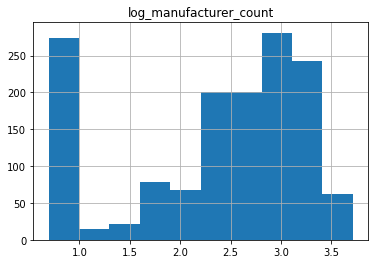

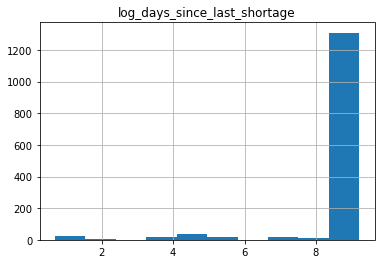


complexity_Low value counts:
complexity_Low
False    889
True     554
Name: count, dtype: int64

complexity_Medium value counts:
complexity_Medium
False    1404
True       39
Name: count, dtype: int64


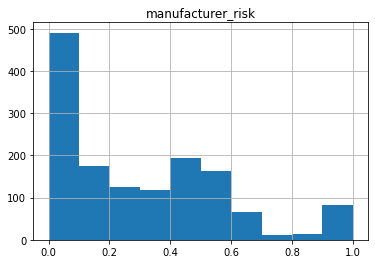

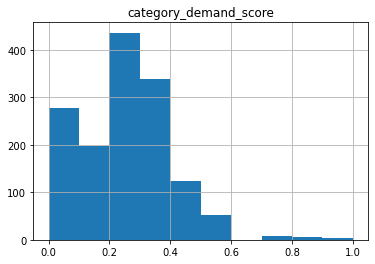


reason_manufacturing value counts:
reason_manufacturing
0    1392
1      51
Name: count, dtype: int64

reason_demand value counts:
reason_demand
0    1351
1      92
Name: count, dtype: int64

is_injectable value counts:
is_injectable
1    849
0    594
Name: count, dtype: int64

is_tablet value counts:
is_tablet
0    1050
1     393
Name: count, dtype: int64

is_capsule value counts:
is_capsule
0    1302
1     141
Name: count, dtype: int64


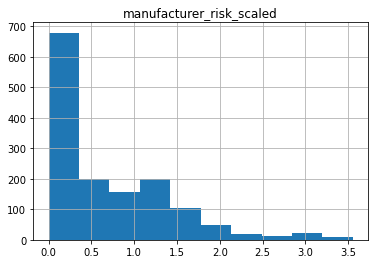

In [163]:
for col in features:
    if df_merged[col].nunique() <= 2:
        print(f"\n{col} value counts:")
        print(df_merged[col].value_counts())
    else:
        df_merged[col].hist()
        plt.title(col)
        plt.show()

#### Modelling

In [164]:
df_model = df_merged.drop_duplicates(subset=['generic_name', 'initial_posting_date'])

In [165]:
X = df_model[features]
y = df_model['future_shortage']

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [168]:
models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight='balanced'),
    
    "RandomForest": RandomForestClassifier(n_estimators=500, random_state=42),
    
    "GradientBoosting": GradientBoostingClassifier(n_estimators=500, random_state=42),
    
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=3,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

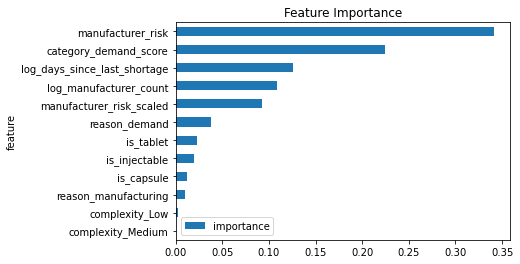

In [169]:
best_model = GradientBoostingClassifier(n_estimators=500, random_state=42)

best_model.fit(X_train, y_train)

importance = pd.DataFrame({
    'feature': features,
    'importance': best_model.feature_importances_
}).sort_values(by='importance')

importance.plot(x='feature', y='importance', kind='barh')
plt.title("Feature Importance")
plt.show()

In [170]:
importance

,feature,importance
3,complexity_Medium,0.000647
2,complexity_Low,0.003080
6,reason_manufacturing,0.010377
10,is_capsule,0.011817
8,is_injectable,0.019491
9,is_tablet,0.022945
7,reason_demand,0.038175
11,manufacturer_risk_scaled,0.093154
0,log_manufacturer_count,0.108294
1,log_days_since_last_shortage,0.125958


In [171]:
y_probs = best_model.predict_proba(X_test)[:, 1]

df_results = X_test.copy()
df_results['generic_name'] = df_merged.loc[X_test.index, 'generic_name']
df_results['risk_score'] = y_probs

df_results.sort_values(by='risk_score', ascending=False)[['generic_name', 'risk_score']].head(10)

,generic_name,risk_score
1186,Lidocaine Hydrochloride Injection,1.000000
836,Ropivacaine Hydrochloride Injection,1.000000
14,Dexmedetomidine Hydrochloride Injection,0.999951
435,Hydromorphone Hydrochloride Injection,0.994699
82,Dextrose Monohydrate 50% Injection,0.993736
356,Lidocaine Hydrochloride Injection,0.924023
601,Lorazepam Injection,0.807669
361,Dexamethasone Sodium Phosphate Injection,0.702622
79,Lorazepam Injection,0.670472
44,Ketorolac Tromethamine Injection,0.298732


In [172]:
df_results['risk_score'].describe()

count    4.200000e+01
mean     1.999803e-01
std      3.772746e-01
min      6.355240e-09
25%      1.014959e-06
50%      2.280302e-05
75%      2.305860e-03
max      1.000000e+00
Name: risk_score, dtype: float64

##### Threshold Selection

Threshold =0.3 used to prioritize recall, ensuring high-risk drugs are identified even at the cost of false positives

In [173]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > 0.3).astype(int)
    
    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, y_probs),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by='roc_auc', ascending=False)

results_df

c:\Users\hansi\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [20:13:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,model,roc_auc,accuracy,precision,recall,f1_score
0,Logistic,0.800000,0.619048,0.285714,0.857143,0.428571
1,RandomForest,0.767347,0.785714,0.416667,0.714286,0.526316
2,GradientBoosting,0.763265,0.809524,0.444444,0.571429,0.500000
3,XGBoost,0.755102,0.809524,0.444444,0.571429,0.500000


c:\Users\hansi\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [20:13:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


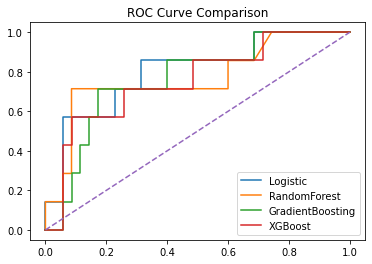

In [174]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

#### Dashboard

In [175]:
# wrap your best model
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid')

# fit on training data
calibrated_model.fit(X_train, y_train)

# save this instead of old model
dump(calibrated_model, "model.joblib")

['model.joblib']

In [176]:
df_model.to_csv("final_dataset.csv", index=False)

##### Model Performance and Insights
Performance of multiple models evaluated using ROC-AUC, accuracy, precision, recall, and F1-score:

- **Logistic Regression** highest ROC-AUC (~0.80) = strong ability to distinguish between future shortage vs non-shortage events
    - Also achieved **high recall (~0.86)** = effective at identifying potential shortages 
- **Random Forest, Gradient Boosting, XGBoost** = showed higher accuracy but slightly lower ROC-AUC

##### Interpretation

- Higher recall prioritized as missing a potential shortage is more costly than a false positive
- Tree-based models offer better balance, but Logistic Regression provides:
  - Strong interpretability
  - Reliable ranking of risk probabilities

##### Feature Importance (Gradient Boosting)

The most important drivers of shortage risk are:

1. **Manufacturer Risk (~0.34)**  
   - Strongest predictor  
   - Indicates historical instability of suppliers  

2. **Category Demand Score (~0.22)**  
   - High-demand therapeutic categories are more prone to shortages  

3. **Days Since Last Shortage (~0.13)**  
   - Recency of past disruptions is a key signal  

4. **Manufacturer Count (~0.11)**  
   - Lower supplier diversification increases risk  

5. **Manufacturer Risk (Scaled) (~0.09)**  
   - Interaction between supplier instability and diversification  

##### Key Insights

- **Supply-side factors dominate risk prediction**
  - Manufacturer behavior is the most critical driver  
- **Demand pressure contributes significantly**
  - Certain therapeutic categories consistently face higher shortages  
- **Historical patterns matter**
  - Recurring shortages are strong predictors of future disruptions  

##### Final Model Selection

**Gradient Boosting** is selected as the final model for deployment because:

- Strong overall performance across metrics  
- Balanced precision and recall  
- Robust handling of non-linear relationships  
- Stable feature importance interpretation  

##### Output: Risk Scoring

The final model generates a **risk score (probability of future shortage)** for each drug:

- Values range from **0 to 1**
- Higher score → higher likelihood of future shortage  

Example use:
- **0.8+ → High risk (requires immediate attention)**
- **0.5–0.8 → Moderate risk**
- **<0.5 → Lower risk**

##### Business Application

This output feeds directly into the dashboard, enabling:

- Identification of high-risk drugs  
- Prioritization of supply chain interventions  
- Monitoring of supplier reliability  
- Strategic inventory and procurement decisions  